In [1]:
import os

import pandas as pd
import torch
import torch.nn as nn
from datasets import Dataset
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoConfig
from transformers import AutoModel, AutoTokenizer
from transformers import Trainer, TrainingArguments
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
huggingface_access_token = ""
print(device)

C:\Users\nishi\PythonProject\ImageForensics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
def get_company_dataset(company, tokenizer, max_length=128, test_size=0.2):
    df = pd.read_csv(f"{company}_data_v2.csv")

    #  Label Encoding (Local to this company/dataset)
    # If global consistency needed across companies, pass fitted encoders instead.
    type_encoder = LabelEncoder()
    code_encoder = LabelEncoder()

    df['cc_type_id'] = type_encoder.fit_transform(df['cc_type'])
    df['cc_code_id'] = code_encoder.fit_transform(df['cc_code'])

    type_id_to_label = {str(i): str(label) for i, label in enumerate(type_encoder.classes_)}
    code_id_to_label = {str(i): str(label) for i, label in enumerate(code_encoder.classes_)}

    with open(f'type_id_to_label_{company}.json', 'w') as f:
        json.dump(type_id_to_label, f)

    with open(f'code_id_to_label_{company}.json', 'w') as f:
        json.dump(code_id_to_label, f)

    # Calculate dimensions for the model heads
    num_type_labels = len(type_encoder.classes_)
    num_code_labels = len(code_encoder.classes_)

    print(f"Dataset Loaded: {len(df)} records")
    print(f"Found {num_type_labels} Transaction Types and {num_code_labels} GL Codes.")

    # 3. Stratified Train/Test Split
    # We create a temporary 'stratify_col' to ensure both Type and Code distributions are preserved
    df['stratify_col'] = df['cc_type'].astype(str) + "_" + df['cc_code'].astype(str)

    train_df, val_df = train_test_split(
        df,
        test_size=test_size,
        random_state=42,
        stratify=df['stratify_col']  # Critical for rare GL codes
    )
    #company_a_data_40classes.csv
    train_df.to_csv(f"Training_Data_{company}.csv", index=False)
    val_df.to_csv(f"Val_Data_{company}.csv", index=False)

    val_metadata = val_df[
        ['merchant_group', 'merchant_name', 'merchant_category', 'amount', 'currency', 'description', 'cc_type',
         'cc_code']].reset_index(drop=True)

    # Cleanup auxiliary columns
    cols_to_keep = ['merchant_group', 'merchant_name', 'merchant_category', 'amount', 'currency', 'cc_type_id',
                    'cc_code_id']
    train_df = train_df[cols_to_keep]
    val_df = val_df[cols_to_keep]

    # 4. Convert to Hugging Face Datasets
    train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
    val_dataset = Dataset.from_pandas(val_df, preserve_index=False)

    def bucketize_amount(amount):
        try:
            val = float(amount)
            # Handle negative (refunds/credits) separately if needed
            is_negative = val < 0
            val = abs(val)

            if val == 0:
                bucket = "ZERO"
            elif val < 10:
                bucket = "XS"  # e.g., < $10 (Coffee, fast food)
            elif val < 50:
                bucket = "SMALL"  # e.g., $10-$50 (Groceries, gas)
            elif val < 100:
                bucket = "MEDIUM"  # e.g., $50-$100 (Utilities, clothes)
            elif val < 500:
                bucket = "LARGE"  # e.g., $100-$500 (Electronics, furniture)
            elif val < 1000:
                bucket = "XL"  # e.g., $500-$1000 (Rent, high-end)
            else:
                bucket = "XXL"  # e.g., > $1000 (B2B payments, salary)

            prefix = "REFUND_" if is_negative else ""
            return f"{prefix}{bucket}"
        except (ValueError, TypeError):
            return "UNKNOWN"

    # 5. Tokenization Function
    def preprocess_function(examples):
        # Manual concatenation for Gemma/LLMs
        inputs = [
            f"Merchant: {name} | Group: {group} | Category: {cat} | Amount: {bucketize_amount(amt)} | currency: {curr} "
            for name, group, cat, amt, curr in zip(
                examples["merchant_name"],
                examples["merchant_group"],
                examples["merchant_category"],
                examples["amount"],
                examples["currency"],
            )
        ]

        tokenized_inputs = tokenizer(
            inputs,  # Single list of strings
            truncation=True,
            max_length=max_length,
            padding="max_length"  # Or False if using DataCollator
        )

        tokenized_inputs["labels_type"] = examples["cc_type_id"]
        tokenized_inputs["labels_code"] = examples["cc_code_id"]
        return tokenized_inputs

    # 6. Apply Processing
    # We remove the text columns to leave only the tensors
    remove_cols = train_dataset.column_names

    train_dataset = train_dataset.map(preprocess_function, batched=True, remove_columns=remove_cols)
    val_dataset = val_dataset.map(preprocess_function, batched=True, remove_columns=remove_cols)

    # 7. Set Format for PyTorch
    target_columns = ["input_ids", "attention_mask", "labels_type", "labels_code"]
    train_dataset.set_format(type="torch", columns=target_columns)
    val_dataset.set_format(type="torch", columns=target_columns)

    return {
        "train": train_dataset,
        "val": val_dataset,
        "val_metadata": val_metadata,
        "num_type_labels": num_type_labels,
        "num_code_labels": num_code_labels,
        "encoders": {"type": type_encoder, "code": code_encoder}

    }


In [3]:
from transformers import AutoModelForCausalLM


class GemmaMultiHeadClassifier(nn.Module):
    def __init__(self, model_id, num_type_labels, num_code_labels, lora_config=None):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_id,  token=huggingface_access_token)

        self.Gemma = AutoModelForCausalLM.from_pretrained(
            model_id,
            trust_remote_code=True,
            device_map=None,
            token=huggingface_access_token
        )

        # print(f"VANILLA Gemma ARCHITECTURE : \n {self.Gemma}")

        if lora_config is not None:
            self.Gemma = get_peft_model(self.Gemma, lora_config)

            self.Gemma.print_trainable_parameters()

        # Two separate Head for Code and Type , hiodeen size of model , 1536 for Gemma .

        self.type_head = nn.Linear(self.config.hidden_size, num_type_labels)
        self.code_head = nn.Linear(self.config.hidden_size, num_code_labels)

        # changing heads added to Gemma Data Type DFloat16 
        self.type_head.to(self.Gemma.dtype)
        self.code_head.to(self.Gemma.dtype)

        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask=None,
                labels_type=None, labels_code=None, labels=None, **kwargs):

        if labels is not None:
            labels_type = labels[:, 0]  # Assuming first col is type
            labels_code = labels[:, 1]  # Assuming second col is code

        outputs = self.Gemma(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True
        )
        # Extract Last Token Embedding (EOS token), for LLMs, use Last Hidden State of last token
        # shape : [batch, seq_length, hidden]
        # AutoModelForCausalLM might not return 'last_hidden_state' attribute directly in some versions,
        # but 'hidden_states' tuple is always there if output_hidden_states=True.

        if hasattr(outputs, "last_hidden_state"):
            last_hidden_state = outputs.last_hidden_state
        else:
            # Fallback: Get the last layer from the hidden_states tuple
            last_hidden_state = outputs.hidden_states[-1]

        #print( "Shape of last hidden state %",last_hidden_state.shape )
        #Shape of last hidden state = torch.Size([32, 64, 1536])
        # Get Embedding of last token for Classification
        pooled_output = last_hidden_state[:, -1, :]


        # Get the Vector for last token in the sequence using sequence lenght calced above
        #last_hidden_state shape: (Batch_Size, Sequence_Length, Hidden_Size)
        # last_hidden_state[0] = batch size
        # sequence_lengths contains last token indexes for each sequence .
        # Last token is sequence is like CLS token it has learnt about the sequence
        #pooled_output = last_hidden_state[torch.arange(last_hidden_state.shape[0]), sequence_lengths]

        # Pass it to the linear layers like we do CLS Token in Transforemrs
        logits_type = self.type_head(pooled_output)
        logits_code = self.code_head(pooled_output)

        loss = None

        if labels_type is not None and labels_code is not None:
            loss_type = self.loss_fn(logits_type, labels_type)
            loss_code = self.loss_fn(logits_code, labels_code)
            loss = 2 * loss_type + 1 * loss_code
        else:
            loss = torch.tensor(0.0, device=input_ids.device, requires_grad=True)

        # Form output that can work with Huggingface trainer
        output = {
            "logits": (logits_type, logits_code)
        }

        return {
            "loss": loss,
            "logits": (logits_type, logits_code),
            # Trainer accepts tuples here if you handle them in compute_metrics
            "hidden_states": outputs.hidden_states,
            "attentions": outputs.attentions,
        }



In [4]:

import evaluate


class CustomTrainer(Trainer):
    def save_model(self, output_dir=None, _internal_call=False):
        # Save the LoRA adapters (standard behavior)
        # Checks if model is wrapped in PEFT
        if output_dir is None:
            output_dir = self.args.output_dir

        # Save LoRA weights
        self.model.Gemma.save_pretrained(output_dir)

        # MANUALLY save your custom heads
        torch.save(self.model.type_head.state_dict(), f"{output_dir}/type_head.bin")
        torch.save(self.model.code_head.state_dict(), f"{output_dir}/code_head.bin")

        # Save tokenizer
        self.tokenizer.save_pretrained(output_dir)


# 1. Load the metrics you want
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    # eval_pred is a tuple (predictions, labels)
    logits, labels = eval_pred

    # 2. Convert logits to class predictions (argmax)
    # If your model returns a tuple, you might need logits[0]
    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=-1)

    # 3. Compute metrics
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels,
                           average="weighted")  # Use 'weighted' for multi-class

    # 4. Return a dictionary
    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }


In [5]:
model_id = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True, use_fast=True, token = huggingface_access_token)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
companies = ["company_a", "company_b", "company_c"]  #  list of companies,  "company_E", "company_F"

data_bundle_company_a = get_company_dataset("company_a", tokenizer)
data_bundle_company_b = get_company_dataset("company_b", tokenizer)
data_bundle_company_c = get_company_dataset("company_c", tokenizer)

import joblib

# ... (inside your training loop, after creating data_bundle) ...
print(f"Saving data bundle for companies...")
joblib.dump(data_bundle_company_a, "data_bundle_company_a_v3.pkl")
joblib.dump(data_bundle_company_b, "data_bundle_company_b_v3.pkl")
joblib.dump(data_bundle_company_c, "data_bundle_company_c_v3.pkl")

peft_config = LoraConfig(
    #treat the Gemma backbone as a feature extractor.as we have custom multihead Gemma ,
    # normal classification this would have been SEQ_CLS
    # classification heads are external to the PEFT wrapper here
    task_type=TaskType.CAUSAL_LM,
    r=16,  # 16 RANk is good , LORA Mattrices will be A X R and R X B .
    lora_alpha=32,
    # Scales Output of Lora adapter by Alpha / Rank . ( 32/16 for us) , Makes learnt weights LOUDER compared to base model weights .
    #Scale of 2 is good .
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    # Q K V and Output Projections selected to train as part of adapter
    # MLP Layers are gate_proj, up_proj, down_proj , but results in very large number of paramters to learn but also gives huge accuracy benefit .
    lora_dropout=0.05  # Prevents overfittig whern data sizes are small like our company data case.
)

Dataset Loaded: 2000 records
Found 18 Transaction Types and 16 GL Codes.


Map: 100%|██████████| 400/400 [00:00<00:00, 29598.32 examples/s]


Dataset Loaded: 2000 records
Found 19 Transaction Types and 17 GL Codes.


Map: 100%|██████████| 400/400 [00:00<00:00, 30492.39 examples/s]


Dataset Loaded: 2000 records
Found 15 Transaction Types and 17 GL Codes.


Map: 100%|██████████| 400/400 [00:00<00:00, 30407.83 examples/s]

Saving data bundle for companies...


In [6]:

# 4. Training Loop
for company in companies:
    print(f"Training adapter for: {company}")
    # Format: "Merchant Group: {grp} [SEP] Merchant Name: {name}"
    if company == "company_a":
        data_bundle = data_bundle_company_a
    elif company == "company_b":
        data_bundle = data_bundle_company_b
    elif company == "company_c":
        data_bundle = data_bundle_company_c

    train_dataset = data_bundle["train"]
    val_dataset = data_bundle["val"]
    num_type_labels = data_bundle["num_type_labels"]
    num_code_labels = data_bundle["num_code_labels"]

    model = GemmaMultiHeadClassifier(
        model_id=model_id,
        num_type_labels=num_type_labels,
        num_code_labels=num_code_labels,
        lora_config=peft_config
    )

    model.Gemma.resize_token_embeddings(len(tokenizer))

    for param in model.type_head.parameters(): param.requires_grad = True
    for param in model.code_head.parameters(): param.requires_grad = True

    # C. Train
    training_args = TrainingArguments(
        output_dir=f"./results/{company}",
        per_device_train_batch_size=16,  # Reduced from 32 (longer sequences)
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=2,  # Effective batch = 16*2 = 32
        num_train_epochs=6,
        learning_rate=2e-4,
        warmup_steps=50,
        max_grad_norm=0.3,
        label_names=["labels_type", "labels_code"],
        # Strategy
        #eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        remove_unused_columns=False
    )

    custom_trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset
    )

    custom_trainer.train()
    print(f"Peak memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

    metrics = custom_trainer.evaluate(eval_dataset=val_dataset)
    print(metrics)

    save_path = f"./final_adapters_Gemma/{company}"

    # Save Adapter & Heads
    # This saves the LoRA weights
    model.Gemma.save_pretrained(save_path)
    torch.save(model.type_head.state_dict(), os.path.join(save_path, "type_head.bin"))
    torch.save(model.code_head.state_dict(), os.path.join(save_path, "code_head.bin"))

    # 6. Clean up
    del model
    torch.cuda.empty_cache()


Training adapter for: company_a


Loading weights: 100%|██████████| 340/340 [00:00<00:00, 1524.84it/s, Materializing param=model.norm.weight]                                


trainable params: 2,981,888 || all params: 1,002,867,840 || trainable%: 0.2973


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Step,Training Loss
50,8.653125
100,5.004531
150,0.906829
200,0.146938
250,0.022995
300,0.001549


...

trainable params: 2,981,888 || all params: 1,002,867,840 || trainable%: 0.2973


Step,Training Loss
50,8.936875
100,5.238203
150,1.043911
200,0.187526
250,0.014897
300,0.000725


Peak memory: 8.41 GB


{'eval_loss': 0.011645049788057804, 'eval_runtime': 28.2791, 'eval_samples_per_second': 14.145, 'eval_steps_per_second': 0.46, 'epoch': 6.0}


C:\Users\nishi\PythonProject\ImageForensics\.venv\Lib\site-packages\peft\utils\other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69974baa-334c109e05cba2b4365bfa14;24e7bf4b-e427-48c5-9f99-aea52432a497)

Cannot access gated repo for url https://huggingface.co/google/gemma-3-1b-it/resolve/main/config.json.
Access to model google/gemma-3-1b-it is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in google/gemma-3-1b-it.
  warnings.warn(


In [7]:
model_id = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True, use_fast=True, token= huggingface_access_token)
tokenizer.pad_token = tokenizer.eos_token
peft_config = LoraConfig(
    #treat the Gemma backbone as a feature extractor.as we have custom multihead Gemma ,
    # normal classification this would have been SEQ_CLS
    # classification heads are external to the PEFT wrapper here
    task_type=TaskType.CAUSAL_LM,
    r=16,  # 16 RANk is good , LORA Mattrices will be A X R and R X B .
    lora_alpha=32,
    # Scales Output of Lora adapter by Alpha / Rank . ( 32/16 for us) , Makes learnt weights LOUDER compared to base model weights .
    #Scale of 2 is good .
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    # Q K V and Output Projections selected to train as part of adapter
    # MLP Layers are gate_proj, up_proj, down_proj , but results in very large number of paramters to learn but also gives huge accuracy benefit .
    lora_dropout=0.05  # Prevents overfittig whern data sizes are small like our company data case.
)

Loading Base Model (this takes time)...


Loading weights: 100%|██████████| 340/340 [00:00<00:00, 1441.46it/s, Materializing param=model.norm.weight]                                


Fetching data for company_a...
Loading cached data bundle for company_a...

--- Validating: company_a ---
Loading heads -> Types: 18, Codes: 16
Running Inference...


✅ Predictions saved to: predictions_company_a.csv

--- Prediction Sample for company_a ---
Idx   Merchant                       Act. Code            Pred. Code           Match
-------------------------------------------------------------------------------------
0     Merchant_1083 OTE              COMPANY_A-246316     COMPANY_A-246316     ✅    
1     Merchant_1629 AFI              COMPANY_A-198246     COMPANY_A-198246     ✅    
2     Merchant_563 VMN               COMPANY_A-334053     COMPANY_A-334053     ✅    
3     Merchant_2036 ABQ              COMPANY_A-246316     COMPANY_A-246316     ✅    
4     Merchant_772 AKF               COMPANY_A-872246     COMPANY_A-872246     ✅    
5     Merchant_443 OGU               COMPANY_A-671858     COMPANY_A-671858     ✅    
6     Merchant_4630 PNY              COMPANY_A-207473     COMPANY_A-207473     ✅    
7     Merchant_580 BGG               COMPANY_A-246316     COMPANY_A-246316     ✅    
8     Merchant_656 FZB               COMPANY_A-877572     

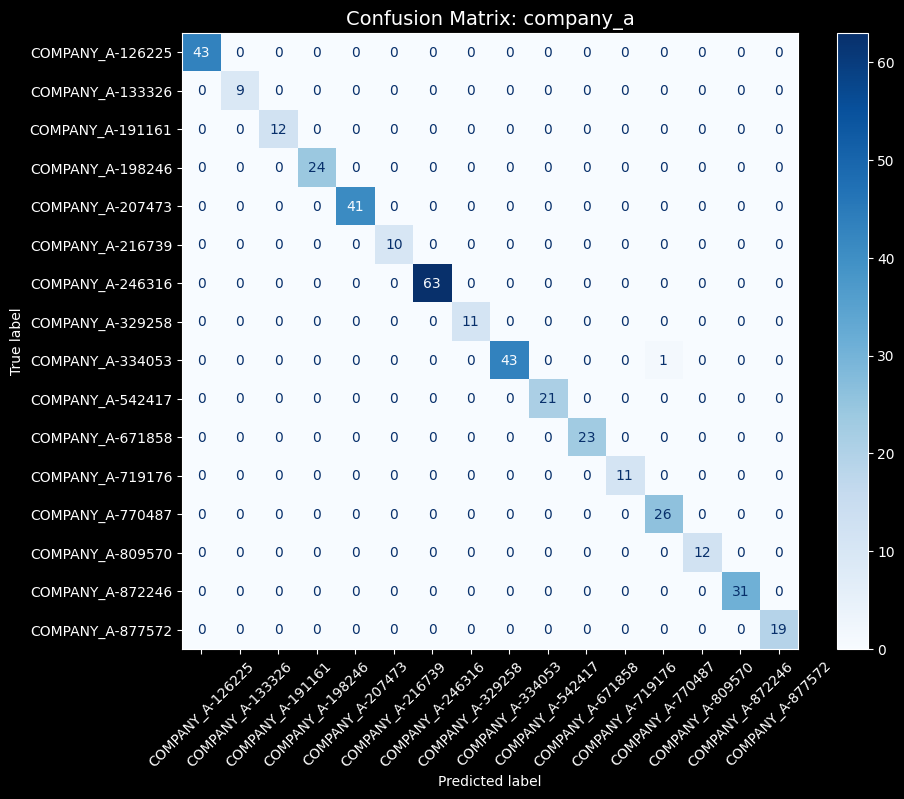

⚠️ Could not plot confusion matrix: y contains previously unseen labels: [16 17]
Fetching data for company_b...
Loading cached data bundle for company_b...

--- Validating: company_b ---
Loading heads -> Types: 19, Codes: 17
Running Inference...


C:\Users\nishi\PythonProject\ImageForensics\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:1466: UserWarning: Adapter company_a was active which is now deleted. Setting active adapter to default.
  warnings.warn(


✅ Predictions saved to: predictions_company_b.csv

--- Prediction Sample for company_b ---
Idx   Merchant                       Act. Code            Pred. Code           Match
-------------------------------------------------------------------------------------
0     Merchant_4060 OXF              COMPANY_B-708067     COMPANY_B-708067     ✅    
1     Merchant_3303 OAA              COMPANY_B-810725     COMPANY_B-810725     ✅    
2     Merchant_4490 EXQ              COMPANY_B-154321     COMPANY_B-154321     ✅    
3     Merchant_2181 IUH              COMPANY_B-154321     COMPANY_B-154321     ✅    
4     Merchant_3075 TSV              COMPANY_B-895474     COMPANY_B-895474     ✅    
5     Merchant_1203 WEI              COMPANY_B-105851     COMPANY_B-105851     ✅    
6     Merchant_4763 IXO              COMPANY_B-895474     COMPANY_B-895474     ✅    
7     Merchant_3601 ZSP              COMPANY_B-895474     COMPANY_B-895474     ✅    
8     Merchant_3303 OAA              COMPANY_B-810725     

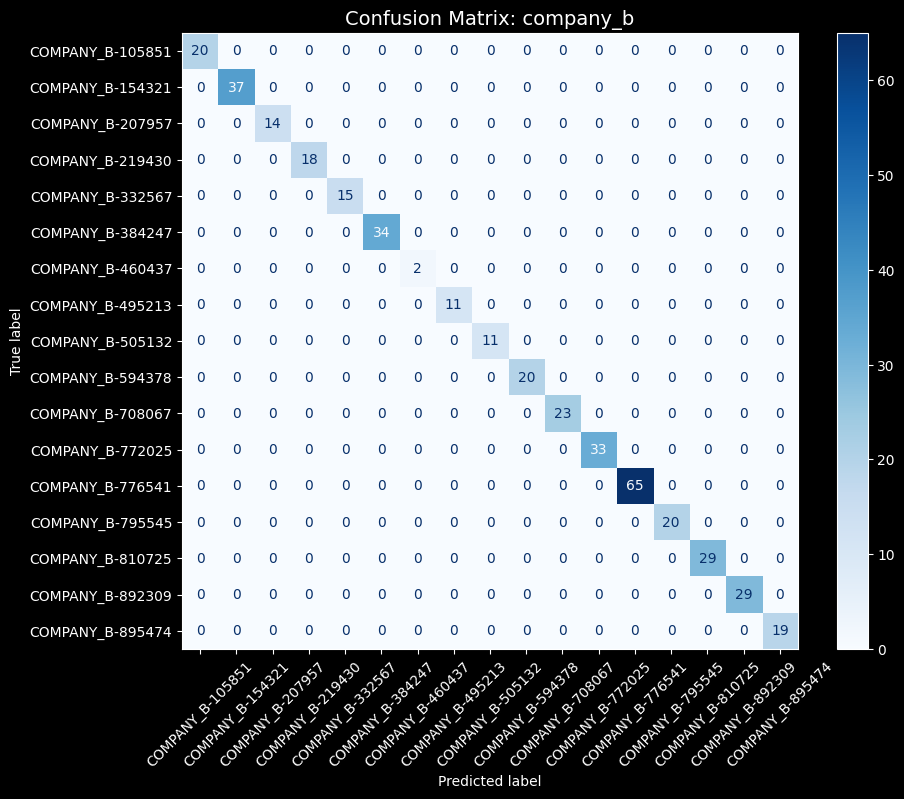

⚠️ Could not plot confusion matrix: y contains previously unseen labels: [17 18]
Fetching data for company_c...
Loading cached data bundle for company_c...

--- Validating: company_c ---
Loading heads -> Types: 15, Codes: 17
Running Inference...


C:\Users\nishi\PythonProject\ImageForensics\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:1466: UserWarning: Adapter company_b was active which is now deleted. Setting active adapter to default.
  warnings.warn(


✅ Predictions saved to: predictions_company_c.csv

--- Prediction Sample for company_c ---
Idx   Merchant                       Act. Code            Pred. Code           Match
-------------------------------------------------------------------------------------
0     Merchant_1089 LRR              COMPANY_C-993329     COMPANY_C-993329     ✅    
1     Merchant_1904 OXU              COMPANY_C-608678     COMPANY_C-608678     ✅    
2     Merchant_4645 MHS              COMPANY_C-160189     COMPANY_C-160189     ✅    
3     Merchant_4375 ZXZ              COMPANY_C-725545     COMPANY_C-725545     ✅    
4     Merchant_1339 OBK              COMPANY_C-892494     COMPANY_C-892494     ✅    
5     Merchant_2271 VNW              COMPANY_C-520557     COMPANY_C-520557     ✅    
6     Merchant_740 SNZ               COMPANY_C-993329     COMPANY_C-993329     ✅    
7     Merchant_2640 CEO              COMPANY_C-142907     COMPANY_C-142907     ✅    
8     Merchant_2514 GJH              COMPANY_C-725545     

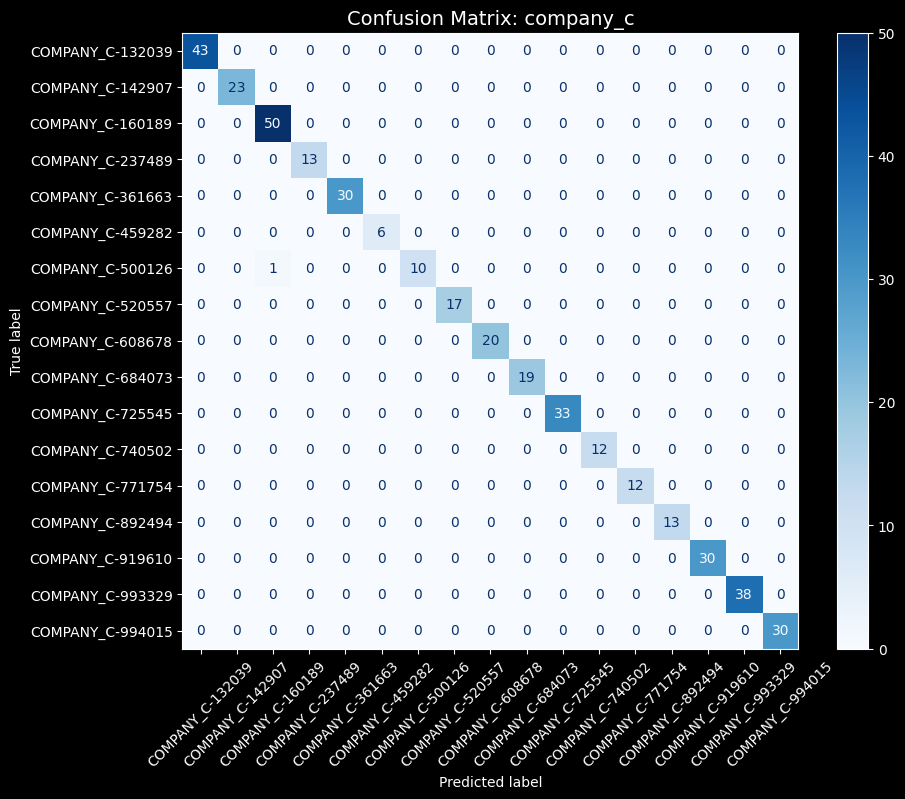

Generating Confusion Matrix for GL Types...


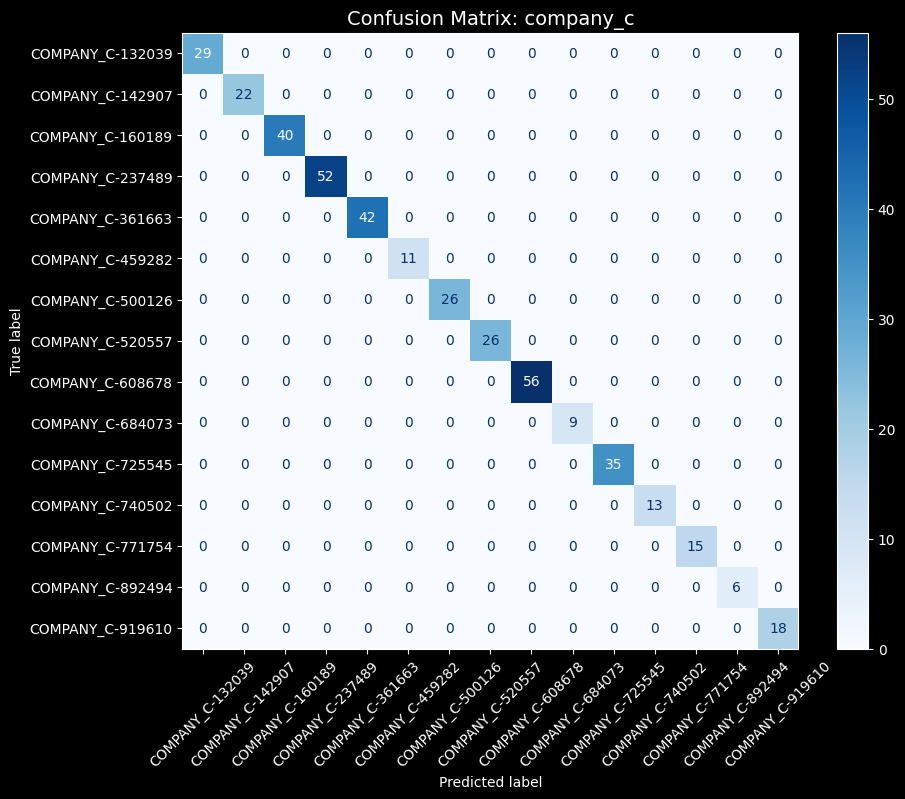


=== Final Results Summary ===
[{'company': 'company_a', 'acc_code': 0.9975}, {'company': 'company_b', 'acc_code': 1.0}, {'company': 'company_c', 'acc_code': 0.9975}]


C:\Users\nishi\PythonProject\ImageForensics\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:1466: UserWarning: Adapter company_c was active which is now deleted. Setting active adapter to default.
  warnings.warn(


In [8]:
import torch
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, Trainer, TrainingArguments, AutoModel
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, \
    ConfusionMatrixDisplay
import joblib


def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        return logits
    return logits


# Initialize Base Model Wrapper ONCE
print("Loading Base Model (this takes time)...")
# Note: Ensure GemmaMultiHeadClassifier class definition is available above this block
base_model_wrapper = GemmaMultiHeadClassifier(
    model_id=model_id,
    num_type_labels=2,  # Dummy
    num_code_labels=2  # Dummy
)

# CRITICAL FIXES
base_model_wrapper.Gemma.resize_token_embeddings(len(tokenizer))
base_model_wrapper.Gemma = get_peft_model(base_model_wrapper.Gemma, peft_config)
base_model_wrapper.to("cuda")  # Move to GPU


def plot_cm(cm, class_names, title):
    """
    Robust Confusion Matrix Plotter
    """
    # Ensure class names match the matrix size
    # If validation set is small, some classes might be missing from y_true or y_pred
    # confusion_matrix in sklearn returns a matrix of size [n_unique_labels, n_unique_labels]
    # We must trust the labels passed to it.

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Filter for readability if too many classes
    if len(class_names) > 20:
        plt.title(f"{title} (Showing subset)", fontsize=14)
        disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, include_values=False)
    else:
        plt.title(title, fontsize=14)
        disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.show()


# --- 2. Validation Function ---
def validate_company(model, company_name, adapters_root_dir, val_dataset, val_metadata, encoders):
    print(f"\n--- Validating: {company_name} ---")
    adapter_path = os.path.join(adapters_root_dir, company_name)

    if not os.path.exists(adapter_path):
        print(f"❌ Adapter path not found: {adapter_path}")
        return None

    # A. Dynamic Head Resizing (Crucial Step)
    try:
        # Load state dicts to CPU first
        type_state = torch.load(os.path.join(adapter_path, "type_head.bin"), map_location="cpu")
        code_state = torch.load(os.path.join(adapter_path, "code_head.bin"), map_location="cpu")

        n_types = type_state['weight'].shape[0]
        n_codes = code_state['weight'].shape[0]

        print(f"Loading heads -> Types: {n_types}, Codes: {n_codes}")

        # Resize the linear layers on the model
        dtype = model.Gemma.dtype
        device = model.Gemma.device

        model.type_head = torch.nn.Linear(model.config.hidden_size, n_types).to(device=device, dtype=dtype)
        model.code_head = torch.nn.Linear(model.config.hidden_size, n_codes).to(device=device, dtype=dtype)

        # Load weights
        model.type_head.load_state_dict(type_state)
        model.code_head.load_state_dict(code_state)

    except FileNotFoundError:
        print(f"❌ Skipping {company_name}: Head weights (bin files) not found.")
        return None

    # B. Load LoRA Adapter
    try:
        # Only load if not already loaded (avoid duplicates error)
        if company_name not in model.Gemma.peft_config:
            model.Gemma.load_adapter(adapter_path, adapter_name=company_name)

        model.Gemma.set_adapter(company_name)
    except Exception as e:
        print(f"❌ Skipping {company_name}: Adapter load failed. {e}")
        return None

    # C. Inference
    eval_trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir="./temp_eval",
            per_device_eval_batch_size=32,
            remove_unused_columns=False,
            report_to="none",
            # Optimization: Use float16 if GPU supports it
            fp16=torch.cuda.is_available()
        ),
        preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    )

    print("Running Inference...")
    preds = eval_trainer.predict(val_dataset, ignore_keys=["loss", "hidden_states", "attentions"])
    logits_type, logits_code = preds.predictions

    # D. Metrics & DataFrame Construction
    pred_types = np.argmax(logits_type, axis=1)
    pred_codes = np.argmax(logits_code, axis=1)

    # Get ground truth from Dataset (guaranteed to be aligned with inputs)
    true_types = np.array(val_dataset['labels_type'])
    true_codes = np.array(val_dataset['labels_code'])

    # Encoders for decoding
    type_encoder = encoders["type"]
    code_encoder = encoders["code"]

    # --- DATAFRAME CREATION ---
    # Important: val_metadata MUST be the exact dataframe used to create val_dataset
    # If val_dataset was shuffled independently, this will be mismatched.
    # Assuming get_company_dataset returns them aligned.

    predictions_df = pd.DataFrame({
        'merchant_name': val_metadata['merchant_name'].values,  # Use .values to ignore index mismatch
        'merchant_group': val_metadata['merchant_group'].values,
        'actual_type_str': val_metadata['cc_type'].values,
        'actual_code_str': val_metadata['cc_code'].values,
        'pred_type_id': pred_types,
        'pred_code_id': pred_codes,
        'true_type_id': true_types,
        'true_code_id': true_codes
    })

    # Add decoded strings
    # Handle cases where predicted ID might be out of range of encoder (rare bug check)
    try:
        predictions_df['pred_type_str'] = type_encoder.inverse_transform(pred_types)
        predictions_df['pred_code_str'] = code_encoder.inverse_transform(pred_codes)
    except ValueError as e:
        print(f"⚠️ Decoding Error: {e}. Check if encoders match the model training!")
        predictions_df['pred_type_str'] = "ERROR"
        predictions_df['pred_code_str'] = "ERROR"

    predictions_df['type_correct'] = predictions_df['pred_type_id'] == predictions_df['true_type_id']
    predictions_df['code_correct'] = predictions_df['pred_code_id'] == predictions_df['true_code_id']

    # Save to CSV
    output_file = f"predictions_{company_name}.csv"
    predictions_df.to_csv(output_file, index=False)
    print(f"✅ Predictions saved to: {output_file}")

    # --- PRINT SAMPLE ---
    print(f"\n--- Prediction Sample for {company_name} ---")
    print(f"{'Idx':<5} {'Merchant':<30} {'Act. Code':<20} {'Pred. Code':<20} {'Match':<5}")
    print("-" * 85)
    for idx in range(min(10, len(predictions_df))):
        row = predictions_df.iloc[idx]
        match = "✅" if row['code_correct'] else "❌"
        print(
            f"{idx:<5} {str(row['merchant_name'])[:28]:<30} {str(row['actual_code_str'])[:18]:<20} {str(row['pred_code_str'])[:18]:<20} {match:<5}")

    # --- METRICS CALCULATION ---
    # Zero Division=0 handles cases where a class is never predicted
    p_code = precision_score(true_codes, pred_codes, average='weighted', zero_division=0)
    r_code = recall_score(true_codes, pred_codes, average='weighted', zero_division=0)
    f1_code = f1_score(true_codes, pred_codes, average='weighted', zero_division=0)
    acc_code = accuracy_score(true_codes, pred_codes)

    p_type = precision_score(true_types, pred_types, average='weighted', zero_division=0)
    r_type = recall_score(true_types, pred_types, average='weighted', zero_division=0)
    f1_type = f1_score(true_types, pred_types, average='weighted', zero_division=0)
    acc_type = accuracy_score(true_types, pred_types)

    print(f"\n=== GL Codes Metrics ({company_name}) ===")
    print(f"Accuracy:  {acc_code:.4f}  {acc_type:.4f}  ")
    print(f"Precision: {p_code:.4f}  {p_type:.4f}  ")
    print(f"Recall:    {r_code:.4f}  {r_type:.4f}  ")
    print(f"F1 Score:  {f1_code:.4f}  {f1_type:.4f}  ")

    # --- CONFUSION MATRIX ---
    # Only compute if we have a manageable number of classes or for debugging
    unique_true_codes = sorted(list(set(true_codes)))
    unique_pred_codes = sorted(list(set(pred_codes)))
    all_labels_present_codes = sorted(list(set(unique_true_codes + unique_pred_codes)))

    unique_true_types = sorted(list(set(true_types)))
    unique_pred_types = sorted(list(set(pred_types)))
    all_labels_present_types = sorted(list(set(unique_true_types + unique_pred_types)))

    # We map these IDs back to strings for the plot labels
    try:
        label_names = code_encoder.inverse_transform(all_labels_present_codes)
        cm_code = confusion_matrix(true_codes, pred_codes, labels=all_labels_present_codes)
        print("Generating Confusion Matrix for GL Codes...")
        plot_cm(cm_code, label_names, f"Confusion Matrix: {company_name}")

        label_names_type = code_encoder.inverse_transform(all_labels_present_types)
        cm_code_type = confusion_matrix(true_types, pred_types, labels=all_labels_present_types)
        print("Generating Confusion Matrix for GL Types...")
        plot_cm(cm_code_type, label_names_type, f"Confusion Matrix: {company_name}")

    except Exception as e:
        print(f"⚠️ Could not plot confusion matrix: {e}")

    # E. Cleanup
    try:
        # Delete adapter to free memory for next company
        model.Gemma.delete_adapter(company_name)
    except:
        pass  # Ignore if delete fails

    torch.cuda.empty_cache()  # Clear GPU memory

    return {"company": company_name, "acc_code": acc_code}


# --- 3. Execution Loop ---
results = []

for company in companies:
    # 1. Get Data Bundle (Ensure this returns 'val', 'val_metadata', 'encoders')
    print(f"Fetching data for {company}...")
    bundle_path = f"data_bundle_{company}_v3.pkl"

    if os.path.exists(bundle_path):
        print(f"Loading cached data bundle for {company}...")
        data_bundle = joblib.load(bundle_path)

    # 2. Validate
    res = validate_company(
        model=base_model_wrapper,
        company_name=company,
        adapters_root_dir="./final_adapters_Gemma",
        val_dataset=data_bundle['val'],
        val_metadata=data_bundle["val_metadata"],
        encoders=data_bundle["encoders"]
    )

    if res:
        results.append(res)

print("\n=== Final Results Summary ===")
print(results)
